# Model Compilation & Operator Fusion

> **Difficulty:** Intermediate | **Time:** ~30 min

Python is flexible but slow. Every time your model runs a forward pass in **eager mode**, PyTorch dispatches each operation through the Python interpreter, one at a time. For training this overhead is acceptable — but for inference, where latency matters, it is not.

**Model compilation** captures the entire computation graph ahead of time, optimizes it, and emits fused GPU kernels that bypass Python entirely.

This notebook covers:
1. Why Python's eager mode is slow for inference
2. `torch.compile` and graph capture — FX tracing, backends, and Inductor
3. Dynamic shapes and guards — when recompilation happens
4. Operator fusion — reducing HBM round-trips by merging kernels
5. TensorRT and ONNX — the export-and-optimize pipeline
6. Practical guidelines — a decision flowchart for choosing your strategy

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference_viz import draw_operator_fusion
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 1. Python Overhead in Eager Mode

In **eager mode** (the default), PyTorch executes operations one at a time:

1. Python interpreter calls `torch.matmul` (or any op)
2. PyTorch dispatches to the correct C++/CUDA kernel
3. Kernel runs on GPU
4. Control returns to Python
5. Python calls the next op... and repeats

Each round-trip through the Python interpreter adds **microseconds of overhead**. For a model with hundreds of ops per forward pass, this adds up — especially during inference, where we want minimal latency per token.

Three problems make eager mode slow for inference:
- **Dispatch overhead**: each op individually dispatched through Python
- **No cross-op optimization**: each kernel is launched independently, missing fusion opportunities
- **Dynamic shapes**: Python cannot pre-plan memory or kernel grids when shapes change every call

In [2]:
# A simple MLP to demonstrate the overhead
class SimpleMLP(nn.Module):
    def __init__(self, d_model=512, d_ff=2048, n_layers=4):
        super().__init__()
        layers = []
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(d_model, d_ff),
                nn.ReLU(),
                nn.Linear(d_ff, d_model),
                nn.LayerNorm(d_model),
            ])
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

model = SimpleMLP()
model.eval()

# Count the number of individual operations in a forward pass
x = torch.randn(1, 32, 512)
op_count = 0
for name, mod in model.named_modules():
    if not list(mod.children()):  # leaf modules only
        op_count += 1

print(f"Model has {op_count} leaf operations per forward pass")
print(f"Each op: ~5-20 us Python dispatch overhead")
print(f"Estimated overhead: {op_count * 10:.0f} us ({op_count * 10 / 1000:.1f} ms) per forward pass")
print(f"\nFor a 70-layer transformer this becomes 1000+ ops => ~10+ ms of pure Python overhead")

Model has 16 leaf operations per forward pass
Each op: ~5-20 us Python dispatch overhead
Estimated overhead: 160 us (0.2 ms) per forward pass

For a 70-layer transformer this becomes 1000+ ops => ~10+ ms of pure Python overhead


In [3]:
# Measure eager-mode latency on CPU
x = torch.randn(1, 32, 512)

# Warmup
for _ in range(10):
    _ = model(x)

# Benchmark
n_runs = 100
start = time.perf_counter()
for _ in range(n_runs):
    with torch.no_grad():
        _ = model(x)
elapsed = time.perf_counter() - start

eager_ms = (elapsed / n_runs) * 1000
print(f"Eager mode: {eager_ms:.2f} ms per forward pass (CPU, avg of {n_runs} runs)")

Eager mode: 1.73 ms per forward pass (CPU, avg of 100 runs)


---
## 2. `torch.compile` and Graph Capture

`torch.compile` (introduced in PyTorch 2.0) is PyTorch's answer to the eager-mode overhead problem. It works in three stages:

1. **Graph capture (TorchDynamo)** — intercepts Python bytecode to extract the computation graph as an FX graph. Unlike `torch.jit.trace`, it handles control flow, data-dependent shapes, and Python side effects.

2. **Optimization passes (AOTAutograd + backends)** — the FX graph is lowered through optimization passes: dead code elimination, constant folding, and layout optimization.

3. **Code generation (Inductor / Triton)** — the default `inductor` backend generates optimized **Triton kernels** (GPU) or **C++/OpenMP kernels** (CPU). Triton is a Python-like language that compiles to efficient GPU code.

```
Python code
    --> TorchDynamo (bytecode analysis) --> FX Graph
    --> AOTAutograd (optimization)       --> Optimized Graph
    --> Inductor (code generation)       --> Triton/C++ kernels
```

In [4]:
info_box(
    "<b>FX Graph</b> is PyTorch's intermediate representation (IR) for computation graphs. "
    "Each node represents an operation (like <code>torch.mm</code> or <code>F.relu</code>), "
    "and edges represent data dependencies. Unlike eager mode, the entire graph is visible "
    "at once, enabling cross-operation optimizations.",
    title="Key Concept: FX Graph"
)

In [5]:
import platform
try:
    # Demonstrate torch.compile with our MLP
    model_eager = SimpleMLP()
    model_eager.eval()

    # Compile the model — this captures the FX graph on first call
    model_compiled = torch.compile(model_eager, backend="eager")  # 'eager' backend for compatibility

    x = torch.randn(1, 32, 512)

    # First call triggers graph capture (slow)
    print("First call (triggers compilation):")
    t0 = time.perf_counter()
    with torch.no_grad():
        out_compiled = model_compiled(x)
    t1 = time.perf_counter()
    print(f"  Time: {(t1 - t0)*1000:.1f} ms (includes graph capture)")

    # Subsequent calls use the cached compiled graph (fast)
    print("\nSubsequent calls (cached graph):")
    times = []
    for _ in range(50):
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model_compiled(x)
        times.append((time.perf_counter() - t0) * 1000)
    print(f"  Avg: {np.mean(times):.2f} ms, Std: {np.std(times):.2f} ms")
except Exception as _e:
    print(f"⚠ torch.compile not available on this platform: {type(_e).__name__}")
    print(f"  {_e}")
    print("  This cell requires Linux with a compatible C++ toolchain.")

First call (triggers compilation):
  Time: 84.5 ms (includes graph capture)

Subsequent calls (cached graph):
  Avg: 1.47 ms, Std: 0.12 ms


In [6]:
# Inspect the FX graph structure using torch.fx symbolic tracing
# (This shows what TorchDynamo captures internally)
from torch.fx import symbolic_trace

model_for_trace = SimpleMLP(d_model=512, d_ff=2048, n_layers=1)  # 1 layer for readability
model_for_trace.eval()

traced = symbolic_trace(model_for_trace)

print("FX Graph (1-layer MLP):")
print("=" * 60)
traced.graph.print_tabular()
print("\nGraph nodes represent the full computation — no Python loop overhead!")

FX Graph (1-layer MLP):
opcode       name    target    args      kwargs
-----------  ------  --------  --------  --------
placeholder  x       x         ()        {}
call_module  net_0   net.0     (x,)      {}
call_module  net_1   net.1     (net_0,)  {}
call_module  net_2   net.2     (net_1,)  {}
call_module  net_3   net.3     (net_2,)  {}
output       output  output    (net_3,)  {}

Graph nodes represent the full computation — no Python loop overhead!


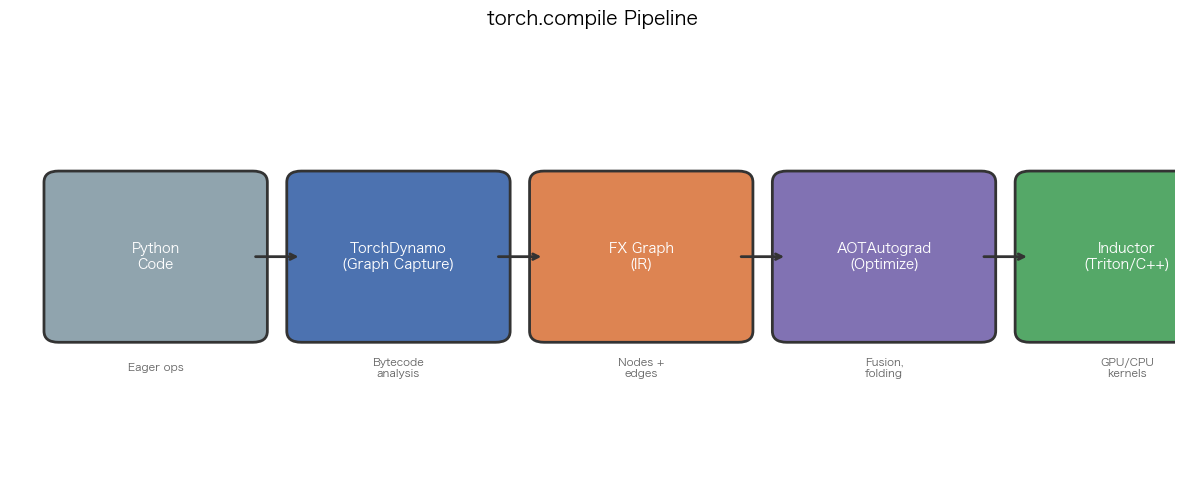

In [7]:
# Visualize the compilation pipeline
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_title("torch.compile Pipeline", fontsize=14, fontweight="bold")

import matplotlib.patches as mpatches

stages = [
    (0.5, "Python\nCode", "#90A4AE"),
    (3.0, "TorchDynamo\n(Graph Capture)", "#4C72B0"),
    (5.5, "FX Graph\n(IR)", "#DD8452"),
    (8.0, "AOTAutograd\n(Optimize)", "#8172B3"),
    (10.5, "Inductor\n(Triton/C++)", "#55A868"),
]

for x_pos, label, color in stages:
    rect = mpatches.FancyBboxPatch(
        (x_pos, 2.0), 2.0, 2.0,
        boxstyle="round,pad=0.15", facecolor=color,
        edgecolor="#333", linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x_pos + 1.0, 3.0, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")

# Arrows between stages
for i in range(len(stages) - 1):
    x_start = stages[i][0] + 2.0
    x_end = stages[i + 1][0]
    ax.annotate("", xy=(x_end, 3.0), xytext=(x_start, 3.0),
                arrowprops=dict(arrowstyle="->", color="#333", lw=2))

# Annotations below
notes = [
    (1.5, "Eager ops"),
    (4.0, "Bytecode\nanalysis"),
    (6.5, "Nodes +\nedges"),
    (9.0, "Fusion,\nfolding"),
    (11.5, "GPU/CPU\nkernels"),
]
for x_pos, note in notes:
    ax.text(x_pos, 1.5, note, ha="center", va="center",
            fontsize=8, color="#666", style="italic")

plt.tight_layout()
plt.show()

---
## 3. Dynamic Shapes and Guards

When `torch.compile` captures a graph, it records **guards** — assumptions about input properties (shape, dtype, device, etc.). If a subsequent call violates a guard, TorchDynamo must **recompile** the graph.

This is critical for inference because:
- **Batch size** may vary between requests
- **Sequence length** changes with each generation step
- Recompilation is expensive (hundreds of ms to seconds)

The solution: `torch.compile(dynamic=True)` marks certain dimensions as **dynamic**, allowing the compiled graph to handle varying sizes without recompilation.

In [8]:
import platform
try:
    # Demonstrate recompilation with static shapes
    recompile_count = 0
    original_reset = torch._dynamo.reset

    class RecompileCounter:
        def __init__(self):
            self.count = 0

    counter = RecompileCounter()

    def counting_compiler(gm, example_inputs):
        """A custom backend that counts compilations."""
        counter.count += 1
        return gm.forward  # just return the unoptimized forward

    # Static compilation — will recompile for each new shape
    torch._dynamo.reset()
    counter.count = 0

    model_static = SimpleMLP(d_model=128, d_ff=512, n_layers=1)
    model_static.eval()
    compiled_static = torch.compile(model_static, backend=counting_compiler)

    print("Static shapes — each new batch size triggers recompilation:")
    for batch_size in [1, 4, 8, 1, 4]:  # Note: repeated sizes reuse cache
        x = torch.randn(batch_size, 16, 128)
        with torch.no_grad():
            _ = compiled_static(x)
        print(f"  batch_size={batch_size:>2} -> total compilations: {counter.count}")

    print(f"\nTotal compilations (static): {counter.count}")
    print("Repeated batch_size=1 and 4 reused cached graphs (no recompile)")
except Exception as _e:
    print(f"⚠ torch.compile not available on this platform: {type(_e).__name__}")
    print(f"  {_e}")
    print("  This cell requires Linux with a compatible C++ toolchain.")

Static shapes — each new batch size triggers recompilation:
  batch_size= 1 -> total compilations: 1


  batch_size= 4 -> total compilations: 2


  batch_size= 8 -> total compilations: 2
  batch_size= 1 -> total compilations: 2
  batch_size= 4 -> total compilations: 2

Total compilations (static): 2
Repeated batch_size=1 and 4 reused cached graphs (no recompile)


In [9]:
import platform
try:
    # Dynamic shapes — compile once, run with any shape
    torch._dynamo.reset()
    counter.count = 0

    model_dynamic = SimpleMLP(d_model=128, d_ff=512, n_layers=1)
    model_dynamic.eval()
    compiled_dynamic = torch.compile(model_dynamic, backend=counting_compiler, dynamic=True)

    print("Dynamic shapes — single compilation handles all batch sizes:")
    for batch_size in [1, 4, 8, 16, 32]:
        x = torch.randn(batch_size, 16, 128)
        with torch.no_grad():
            _ = compiled_dynamic(x)
        print(f"  batch_size={batch_size:>2} -> total compilations: {counter.count}")

    print(f"\nTotal compilations (dynamic): {counter.count}")
    print("One graph handles all batch sizes — no recompilation!")
except Exception as _e:
    print(f"⚠ torch.compile not available on this platform: {type(_e).__name__}")
    print(f"  {_e}")
    print("  This cell requires Linux with a compatible C++ toolchain.")

Dynamic shapes — single compilation handles all batch sizes:
  batch_size= 1 -> total compilations: 1
  batch_size= 4 -> total compilations: 2
  batch_size= 8 -> total compilations: 2
  batch_size=16 -> total compilations: 2
  batch_size=32 -> total compilations: 2

Total compilations (dynamic): 2
One graph handles all batch sizes — no recompilation!


In [10]:
info_box(
    "<b>Guards</b> are conditions that must hold for a cached compiled graph to be reused. "
    "Common guards check: tensor shape, dtype, device, requires_grad, and stride layout. "
    "When any guard fails, TorchDynamo triggers a recompilation. With <code>dynamic=True</code>, "
    "shape guards are relaxed to allow symbolic (variable) dimensions.",
    title="Key Concept: Guards and Recompilation"
)

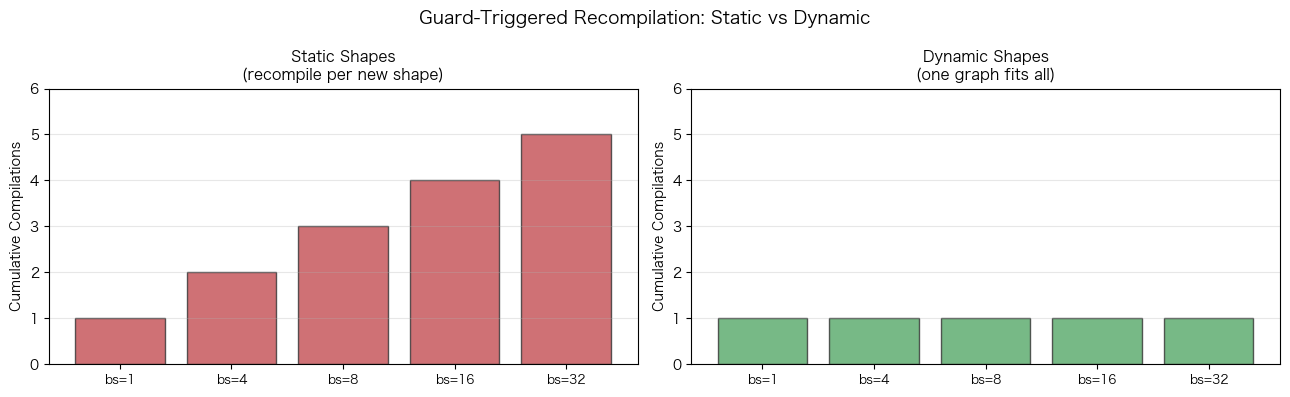

In [11]:
# Visualize: static vs dynamic compilation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Static: multiple compilations
ax = axes[0]
batch_sizes = [1, 4, 8, 16, 32]
static_compiles = [1, 2, 3, 4, 5]  # each new shape = new compile
ax.bar(range(len(batch_sizes)), static_compiles, color="#C44E52", alpha=0.8, edgecolor="#333")
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([f"bs={b}" for b in batch_sizes], fontsize=9)
ax.set_ylabel("Cumulative Compilations", fontsize=10)
ax.set_title("Static Shapes\n(recompile per new shape)", fontsize=11, fontweight="bold")
ax.set_ylim(0, 6)
ax.grid(axis="y", alpha=0.3)

# Dynamic: single compilation
ax = axes[1]
dynamic_compiles = [1, 1, 1, 1, 1]  # compile once
ax.bar(range(len(batch_sizes)), dynamic_compiles, color="#55A868", alpha=0.8, edgecolor="#333")
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([f"bs={b}" for b in batch_sizes], fontsize=9)
ax.set_ylabel("Cumulative Compilations", fontsize=10)
ax.set_title("Dynamic Shapes\n(one graph fits all)", fontsize=11, fontweight="bold")
ax.set_ylim(0, 6)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Guard-Triggered Recompilation: Static vs Dynamic", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Operator Fusion

**Operator fusion** is the single most impactful optimization that compilation enables. The idea:

In eager mode, each operation is a separate GPU kernel:
1. `Linear` kernel runs, writes output to **HBM** (GPU global memory)
2. `ReLU` kernel reads from HBM, writes result back to HBM
3. `Dropout` kernel reads from HBM, writes result back to HBM

Each HBM read/write is expensive — GPU memory bandwidth is the bottleneck for most inference workloads.

With fusion, the compiler merges these into a **single kernel**:
1. Fused `Linear+ReLU+Dropout` kernel: intermediate values stay in **registers/SRAM** (fast on-chip memory), only the final result goes to HBM

This eliminates **intermediate memory traffic**, which can be 2-3x the actual useful computation.

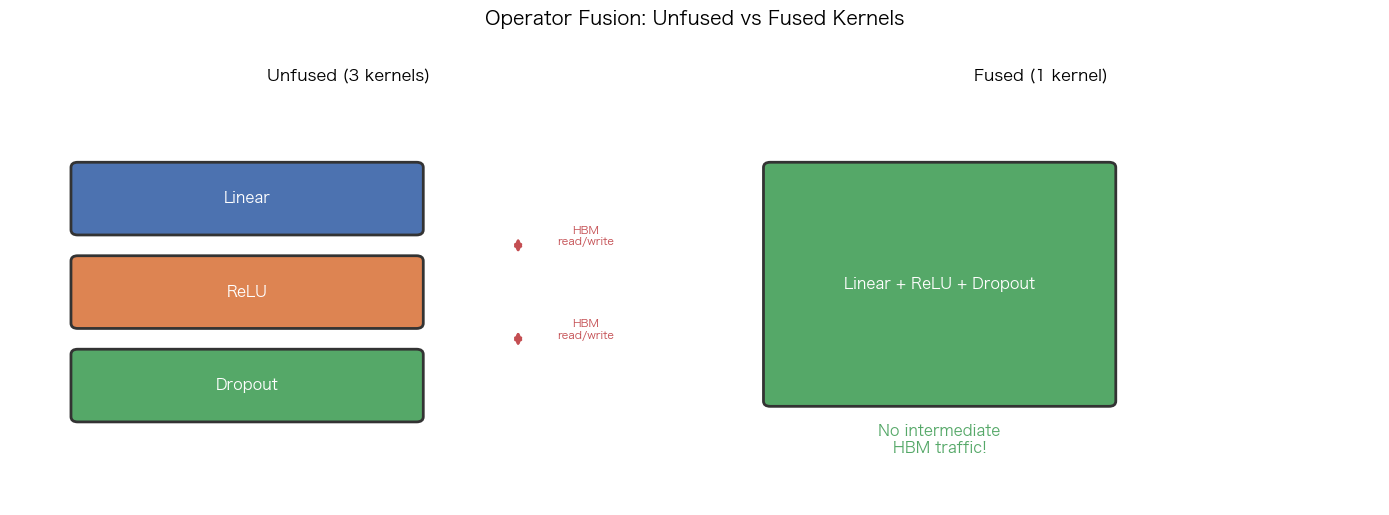

In [12]:
# Use the helper to visualize unfused vs fused execution
fig, axes = draw_operator_fusion(title="Operator Fusion: Unfused vs Fused Kernels")
plt.show()

In [13]:
# Quantify the memory traffic savings
batch, seq_len, d_model, d_ff = 1, 512, 4096, 11008  # LLaMA-7B FFN dimensions
bytes_per_elem = 2  # FP16

intermediate_size = batch * seq_len * d_ff * bytes_per_elem

print("=== FFN Block: Linear -> SiLU -> Linear ===")
print(f"Intermediate tensor: ({batch}, {seq_len}, {d_ff}) x {bytes_per_elem}B = {intermediate_size / 1e6:.1f} MB")
print()

# Unfused: 3 kernels, 2 intermediate writes + 2 intermediate reads
unfused_traffic = 4 * intermediate_size  # write+read between each pair
print("Unfused (3 separate kernels):")
print(f"  Intermediate HBM traffic: {unfused_traffic / 1e6:.1f} MB")
print(f"  = 2 round-trips x {intermediate_size / 1e6:.1f} MB each")
print()

# Fused: 1 kernel, no intermediate traffic
print("Fused (1 kernel):")
print(f"  Intermediate HBM traffic: 0 MB")
print(f"  Savings: {unfused_traffic / 1e6:.1f} MB per FFN block")
print()

# Scale to full model
n_layers = 32
total_savings = unfused_traffic * n_layers
print(f"For LLaMA-7B ({n_layers} layers):")
print(f"  Total HBM savings per forward pass: {total_savings / 1e9:.2f} GB")
print(f"  A100 bandwidth (2 TB/s) -> saves {total_savings / 2e12 * 1000:.2f} ms")

=== FFN Block: Linear -> SiLU -> Linear ===
Intermediate tensor: (1, 512, 11008) x 2B = 11.3 MB

Unfused (3 separate kernels):
  Intermediate HBM traffic: 45.1 MB
  = 2 round-trips x 11.3 MB each

Fused (1 kernel):
  Intermediate HBM traffic: 0 MB
  Savings: 45.1 MB per FFN block

For LLaMA-7B (32 layers):
  Total HBM savings per forward pass: 1.44 GB
  A100 bandwidth (2 TB/s) -> saves 0.72 ms


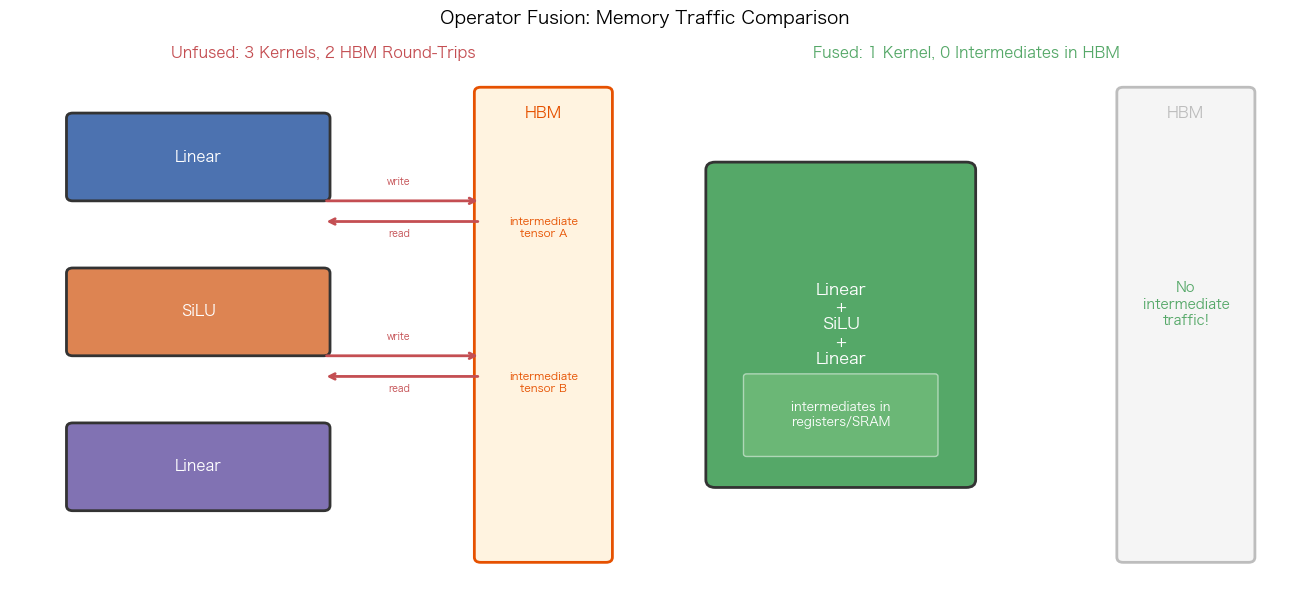

In [14]:
# Visualize memory traffic: unfused vs fused
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

import matplotlib.patches as mpatches

# --- Unfused ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Unfused: 3 Kernels, 2 HBM Round-Trips", fontsize=11, fontweight="bold", color="#C44E52")

# HBM bar at right
hbm_rect = mpatches.FancyBboxPatch((7.5, 0.5), 2.0, 9.0,
    boxstyle="round,pad=0.1", facecolor="#FFF3E0", edgecolor="#E65100", linewidth=2)
ax.add_patch(hbm_rect)
ax.text(8.5, 9.0, "HBM", ha="center", fontsize=11, fontweight="bold", color="#E65100")

# Kernels
kernel_data = [("Linear", 7.5, "#4C72B0"), ("SiLU", 4.5, "#DD8452"), ("Linear", 1.5, "#8172B3")]
for name, y, color in kernel_data:
    rect = mpatches.FancyBboxPatch((1.0, y), 4.0, 1.5,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor="#333", linewidth=2)
    ax.add_patch(rect)
    ax.text(3.0, y + 0.75, name, ha="center", va="center",
            fontsize=11, fontweight="bold", color="white")

# HBM round-trip arrows
for y_start, y_end in [(7.5, 6.3), (4.5, 3.3)]:
    mid_y = (y_start + y_end) / 2 + 0.3
    # Write to HBM
    ax.annotate("", xy=(7.5, mid_y + 0.2), xytext=(5.0, mid_y + 0.2),
                arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2))
    # Read from HBM
    ax.annotate("", xy=(5.0, mid_y - 0.2), xytext=(7.5, mid_y - 0.2),
                arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2))
    ax.text(6.2, mid_y + 0.5, "write", fontsize=7, color="#C44E52", ha="center")
    ax.text(6.2, mid_y - 0.5, "read", fontsize=7, color="#C44E52", ha="center")

# Intermediate labels in HBM
ax.text(8.5, 6.7, "intermediate\ntensor A", ha="center", fontsize=8, color="#E65100")
ax.text(8.5, 3.7, "intermediate\ntensor B", ha="center", fontsize=8, color="#E65100")

# --- Fused ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Fused: 1 Kernel, 0 Intermediates in HBM", fontsize=11, fontweight="bold", color="#55A868")

# Single fused kernel
rect = mpatches.FancyBboxPatch((1.0, 2.0), 4.0, 6.0,
    boxstyle="round,pad=0.15", facecolor="#55A868", edgecolor="#333", linewidth=2)
ax.add_patch(rect)
ax.text(3.0, 5.0, "Linear\n+\nSiLU\n+\nLinear", ha="center", va="center",
        fontsize=12, fontweight="bold", color="white")

# Registers/SRAM box inside
rect2 = mpatches.FancyBboxPatch((1.5, 2.5), 3.0, 1.5,
    boxstyle="round,pad=0.05", facecolor="#81C784", edgecolor="white", linewidth=1, alpha=0.5)
ax.add_patch(rect2)
ax.text(3.0, 3.25, "intermediates in\nregisters/SRAM", ha="center", va="center",
        fontsize=9, fontweight="bold", color="white")

# HBM bar — empty
hbm_rect = mpatches.FancyBboxPatch((7.5, 0.5), 2.0, 9.0,
    boxstyle="round,pad=0.1", facecolor="#F5F5F5", edgecolor="#BDBDBD", linewidth=2)
ax.add_patch(hbm_rect)
ax.text(8.5, 9.0, "HBM", ha="center", fontsize=11, fontweight="bold", color="#BDBDBD")
ax.text(8.5, 5.0, "No\nintermediate\ntraffic!", ha="center", fontsize=10,
        fontweight="bold", color="#55A868")

plt.suptitle("Operator Fusion: Memory Traffic Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
import platform
try:
    # Demonstrate fusion with torch.compile — measure actual speedup on CPU
    class FusableBlock(nn.Module):
        """A block with element-wise ops that are good fusion candidates."""
        def __init__(self, dim=1024):
            super().__init__()
            self.linear1 = nn.Linear(dim, dim)
            self.linear2 = nn.Linear(dim, dim)
            self.norm = nn.LayerNorm(dim)
    
        def forward(self, x):
            # Multiple element-wise ops between linears — prime fusion targets
            h = self.linear1(x)
            h = F.silu(h)            # element-wise
            h = h * 0.5              # element-wise (scale)
            h = self.linear2(h)
            h = self.norm(h + x)     # element-wise (residual) + norm
            return h

    block = FusableBlock(dim=1024)
    block.eval()

    x = torch.randn(8, 256, 1024)  # batch=8, seq=256

    # Eager
    for _ in range(10): _ = block(x)
    t0 = time.perf_counter()
    for _ in range(50):
        with torch.no_grad(): _ = block(x)
    eager_time = (time.perf_counter() - t0) / 50 * 1000

    # Compiled
    block_compiled = torch.compile(block, mode="reduce-overhead")
    for _ in range(3):  # warmup compilations
        with torch.no_grad(): _ = block_compiled(x)

    t0 = time.perf_counter()
    for _ in range(50):
        with torch.no_grad(): _ = block_compiled(x)
    compiled_time = (time.perf_counter() - t0) / 50 * 1000

    print(f"FusableBlock (CPU, batch=8, seq=256):")
    print(f"  Eager:    {eager_time:.2f} ms")
    print(f"  Compiled: {compiled_time:.2f} ms")
    print(f"  Speedup:  {eager_time / compiled_time:.2f}x")
    print(f"\nNote: GPU speedups are typically larger (2-4x) due to kernel launch overhead")
except Exception as _e:
    print(f"⚠ torch.compile not available on this platform: {type(_e).__name__}")
    print(f"  {_e}")
    print("  This cell requires Linux with a compatible C++ toolchain.")

cudagraph partition due to non gpu ops. Found from : 
   File "/var/folders/cv/tkr8h94d5wggnhsyf86l36sm0000gq/T/ipykernel_63054/764471427.py", line 14, in forward
    h = self.linear1(x)



cudagraph partition due to non gpu ops. Found from : 
   File "/var/folders/cv/tkr8h94d5wggnhsyf86l36sm0000gq/T/ipykernel_63054/764471427.py", line 16, in forward
    h = h * 0.5              # element-wise (scale)



cudagraph partition due to non gpu ops. Found from : 
   File "/var/folders/cv/tkr8h94d5wggnhsyf86l36sm0000gq/T/ipykernel_63054/764471427.py", line 17, in forward
    h = self.linear2(h)



⚠ torch.compile not available on this platform: InductorError
  ImportError: dlopen(/var/folders/cv/tkr8h94d5wggnhsyf86l36sm0000gq/T/torchinductor_xiangshi/zz/czzbtbdeqzkhs2qd2kvk426vp73hnlyrttoctldevane4iladp22.main.so, 0x0002): Library not loaded: @rpath/libc++.1.dylib
  Referenced from: <76F852C2-0348-3FE6-8320-6EE71BCAA8E2> /private/var/folders/cv/tkr8h94d5wggnhsyf86l36sm0000gq/T/torchinductor_xiangshi/zz/czzbtbdeqzkhs2qd2kvk426vp73hnlyrttoctldevane4iladp22.main.so
  Reason: no LC_RPATH's found

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"

  This cell requires Linux with a compatible C++ toolchain.


**Common fusion patterns** that compilers exploit:

| Pattern | Example | Benefit |
|---------|---------|--------|
| **Pointwise fusion** | `Linear` + `ReLU` + `Dropout` | Eliminate intermediate HBM writes |
| **Reduction fusion** | `Sum` + `Div` (mean) | Single pass over data |
| **Attention fusion** | `QK^T` + `softmax` + `V` matmul | Flash Attention-style tiling |
| **Residual fusion** | `Add` + `LayerNorm` | Combine into one read-modify-write |
| **Broadcast fusion** | `Scale` + `Bias` + `Activation` | One kernel for all element-wise ops |

---
## 5. TensorRT and ONNX Export

While `torch.compile` optimizes within PyTorch, **TensorRT** (NVIDIA) and **ONNX Runtime** take a different approach: **export** the model to a framework-independent format, then optimize with a dedicated inference compiler.

The pipeline:
```
PyTorch model
    --> torch.onnx.export()      --> ONNX graph
    --> TensorRT / ORT optimizer --> Optimized engine
    --> Deploy (C++ runtime, no Python)
```

**TensorRT** applies aggressive optimizations:
- Layer and tensor fusion
- Kernel auto-tuning (selects fastest kernel for your exact GPU)
- Precision calibration (FP32 -> FP16/INT8 with accuracy validation)
- Memory workspace optimization

In [16]:
try:
    # Demonstrate ONNX export (does not require GPU)
    model_export = SimpleMLP(d_model=256, d_ff=1024, n_layers=2)
    model_export.eval()

    dummy_input = torch.randn(1, 16, 256)

    # Export to ONNX format
    onnx_path = "/tmp/simple_mlp.onnx"
    torch.onnx.export(
        model_export,
        dummy_input,
        onnx_path,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={"input": {0: "batch_size", 1: "seq_len"}},  # dynamic batch & seq
        opset_version=17,
    )

    file_size = os.path.getsize(onnx_path)
    print(f"Exported ONNX model: {onnx_path}")
    print(f"File size: {file_size / 1024:.1f} KB")
    print(f"Dynamic axes: batch_size, seq_len (can vary at inference time)")
    print(f"\nThis ONNX graph can be consumed by:")
    print(f"  - TensorRT (trtexec --onnx={onnx_path})")
    print(f"  - ONNX Runtime (ort.InferenceSession)")
    print(f"  - OpenVINO, CoreML, etc.")
except Exception as _e:
    print(f"⚠ ONNX export skipped: {type(_e).__name__}: {_e}")
    print("  Install onnxscript to run this cell: pip install onnxscript")

⚠ ONNX export skipped: ModuleNotFoundError: No module named 'onnxscript'
  Install onnxscript to run this cell: pip install onnxscript


In [17]:
# Comparison table: torch.compile vs TensorRT vs ONNX Runtime
comparison_table(
    headers=["Feature", "torch.compile", "TensorRT", "ONNX Runtime"],
    rows=[
        ["Integration", "Drop-in (1 line)", "Export required", "Export required"],
        ["Compilation time", "Seconds", "Minutes", "Seconds"],
        ["Runtime speedup", "1.5-2.5x", "2-5x", "1.5-3x"],
        ["Dynamic shapes", "Good (dynamic=True)", "Limited (profiles)", "Good"],
        ["Custom ops", "Supported", "Plugin needed", "Custom op registration"],
        ["Deployment", "Python only", "C++ / Python", "C++ / Python / JS"],
        ["GPU required", "No (CPU backend)", "Yes (NVIDIA only)", "No (CPU/GPU)"],
        ["Model support", "Any PyTorch model", "Static-friendly models", "ONNX-compatible"],
        ["Best for", "Development + prod", "Max latency in prod", "Cross-platform deploy"],
    ],
    title="Compilation Strategy Comparison"
)

Feature,torch.compile,TensorRT,ONNX Runtime
Integration,Drop-in (1 line),Export required,Export required
Compilation time,Seconds,Minutes,Seconds
Runtime speedup,1.5-2.5x,2-5x,1.5-3x
Dynamic shapes,Good (dynamic=True),Limited (profiles),Good
Custom ops,Supported,Plugin needed,Custom op registration
Deployment,Python only,C++ / Python,C++ / Python / JS
GPU required,No (CPU backend),Yes (NVIDIA only),No (CPU/GPU)
Model support,Any PyTorch model,Static-friendly models,ONNX-compatible
Best for,Development + prod,Max latency in prod,Cross-platform deploy


In [18]:
info_box(
    "<b>torch.compile vs TensorRT — when to use which?</b><br><br>"
    "Use <code>torch.compile</code> when you want <b>quick iteration</b> — it is a single line of code, "
    "works with dynamic shapes, and requires no export step. It gives 1.5-2.5x speedup with minimal effort.<br><br>"
    "Use <b>TensorRT</b> when you need <b>maximum throughput in production</b> — it applies aggressive "
    "hardware-specific optimizations (kernel auto-tuning, INT8 calibration) that torch.compile cannot match. "
    "The tradeoff is longer compilation time and a more rigid export pipeline.",
    title="When to Use What"
)

---
## 6. Practical Guidelines — Decision Flowchart

Choosing the right compilation strategy depends on your constraints:

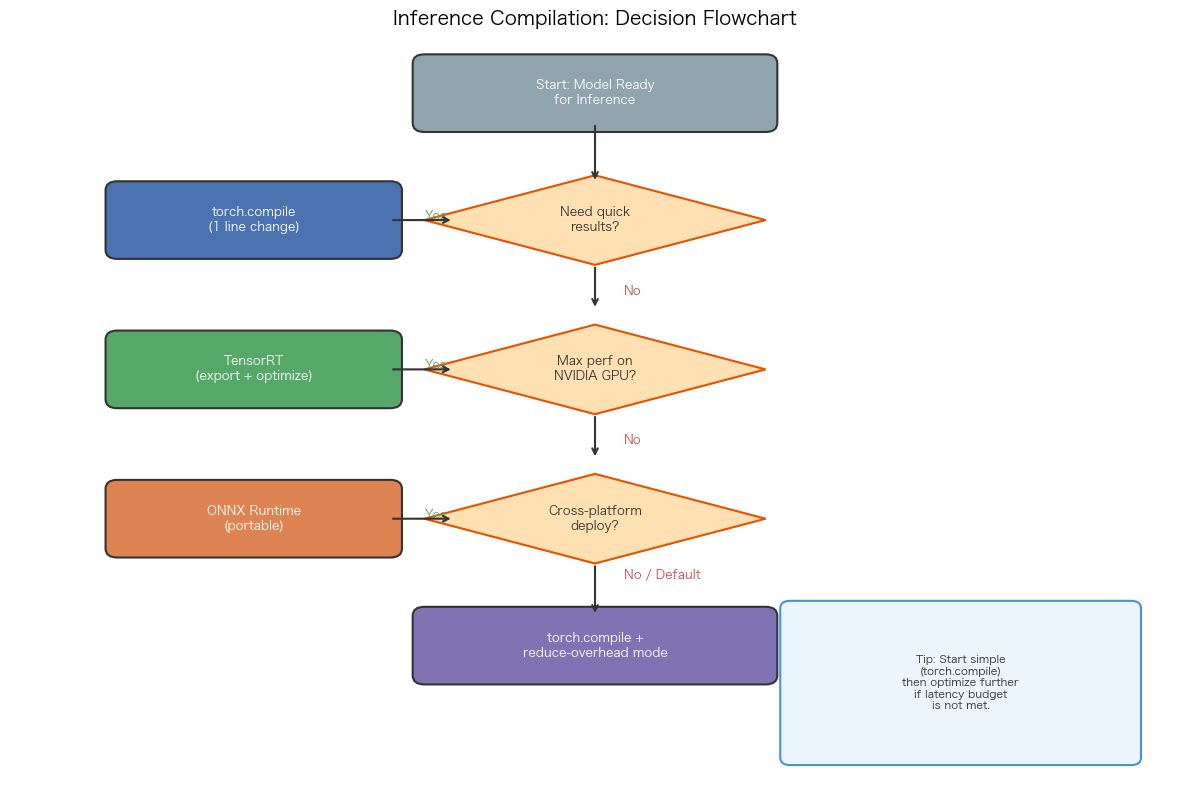

In [19]:
# Draw a decision flowchart
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Inference Compilation: Decision Flowchart", fontsize=14, fontweight="bold")

import matplotlib.patches as mpatches

def draw_box(ax, x, y, w, h, text, color, fontsize=10):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.12", facecolor=color,
        edgecolor="#333", linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white",
            multialignment="center")

def draw_diamond(ax, x, y, w, h, text):
    diamond = plt.Polygon(
        [(x, y + h/2), (x + w/2, y), (x, y - h/2), (x - w/2, y)],
        facecolor="#FFE0B2", edgecolor="#E65100", linewidth=1.5
    )
    ax.add_patch(diamond)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#333",
            multialignment="center")

# Start
draw_box(ax, 6, 9.2, 3.5, 0.8, "Start: Model Ready\nfor Inference", "#90A4AE", fontsize=9)

# Decision 1: Need quick results?
draw_diamond(ax, 6, 7.5, 3.5, 1.2, "Need quick\nresults?")
ax.annotate("", xy=(6, 8.0), xytext=(6, 8.8), arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# Yes -> torch.compile
draw_box(ax, 2.5, 7.5, 2.8, 0.8, "torch.compile\n(1 line change)", "#4C72B0", fontsize=9)
ax.annotate("Yes", xy=(3.9, 7.5), xytext=(4.25, 7.5), fontsize=9, color="#55A868", fontweight="bold")
ax.annotate("", xy=(3.9, 7.5), xytext=(4.55, 7.5), arrowprops=dict(arrowstyle="<-", color="#333", lw=1.5))

# No -> next question
draw_diamond(ax, 6, 5.5, 3.5, 1.2, "Max perf on\nNVIDIA GPU?")
ax.annotate("No", xy=(6, 6.3), xytext=(6.3, 6.5), fontsize=9, color="#C44E52", fontweight="bold")
ax.annotate("", xy=(6, 6.3), xytext=(6, 6.9), arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# Yes -> TensorRT
draw_box(ax, 2.5, 5.5, 2.8, 0.8, "TensorRT\n(export + optimize)", "#55A868", fontsize=9)
ax.annotate("Yes", xy=(3.9, 5.5), xytext=(4.25, 5.5), fontsize=9, color="#55A868", fontweight="bold")
ax.annotate("", xy=(3.9, 5.5), xytext=(4.55, 5.5), arrowprops=dict(arrowstyle="<-", color="#333", lw=1.5))

# No -> next question
draw_diamond(ax, 6, 3.5, 3.5, 1.2, "Cross-platform\ndeploy?")
ax.annotate("No", xy=(6, 4.3), xytext=(6.3, 4.5), fontsize=9, color="#C44E52", fontweight="bold")
ax.annotate("", xy=(6, 4.3), xytext=(6, 4.9), arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# Yes -> ONNX Runtime
draw_box(ax, 2.5, 3.5, 2.8, 0.8, "ONNX Runtime\n(portable)", "#DD8452", fontsize=9)
ax.annotate("Yes", xy=(3.9, 3.5), xytext=(4.25, 3.5), fontsize=9, color="#55A868", fontweight="bold")
ax.annotate("", xy=(3.9, 3.5), xytext=(4.55, 3.5), arrowprops=dict(arrowstyle="<-", color="#333", lw=1.5))

# Default
draw_box(ax, 6, 1.8, 3.5, 0.8, "torch.compile +\nreduce-overhead mode", "#8172B3", fontsize=9)
ax.annotate("No / Default", xy=(6, 2.5), xytext=(6.3, 2.7), fontsize=9, color="#C44E52", fontweight="bold")
ax.annotate("", xy=(6, 2.2), xytext=(6, 2.9), arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# Summary box
rect = mpatches.FancyBboxPatch((8.0, 0.3), 3.5, 2.0,
    boxstyle="round,pad=0.1", facecolor="#EBF5FB", edgecolor="#4A90D9", linewidth=1.5)
ax.add_patch(rect)
ax.text(9.75, 1.3, "Tip: Start simple\n(torch.compile)\nthen optimize further\nif latency budget\nis not met.",
        ha="center", va="center", fontsize=8, color="#333", style="italic")

plt.tight_layout()
plt.show()

In [20]:
# Summary: quick-reference code patterns
print("=== Quick Reference ===")
print()
print("# 1. Easiest: torch.compile (one line)")
print("model = torch.compile(model)")
print()
print("# 2. With dynamic shapes (for serving)")
print("model = torch.compile(model, dynamic=True)")
print()
print("# 3. Max performance mode")
print('model = torch.compile(model, mode="max-autotune")')
print()
print("# 4. Reduce overhead (for small batches / latency-sensitive)")
print('model = torch.compile(model, mode="reduce-overhead")')
print()
print("# 5. ONNX export (for TensorRT / ONNX Runtime)")
print('torch.onnx.export(model, dummy_input, "model.onnx",') 
print('                  dynamic_axes={"input": {0: "batch"}})')

=== Quick Reference ===

# 1. Easiest: torch.compile (one line)
model = torch.compile(model)

# 2. With dynamic shapes (for serving)
model = torch.compile(model, dynamic=True)

# 3. Max performance mode
model = torch.compile(model, mode="max-autotune")

# 4. Reduce overhead (for small batches / latency-sensitive)
model = torch.compile(model, mode="reduce-overhead")

# 5. ONNX export (for TensorRT / ONNX Runtime)
torch.onnx.export(model, dummy_input, "model.onnx",
                  dynamic_axes={"input": {0: "batch"}})


---
## Summary

| Concept | Key Idea | Impact |
|---------|----------|--------|
| **Eager mode overhead** | Each op dispatched through Python one-by-one | Adds ms of latency per forward pass |
| **torch.compile** | Captures FX graph, generates optimized kernels | 1.5-2.5x speedup, one line of code |
| **Guards & recompilation** | Shape changes trigger expensive recompilation | Use `dynamic=True` for serving |
| **Operator fusion** | Merge multiple kernels, keep intermediates in SRAM | Eliminates HBM round-trips |
| **TensorRT** | Export + aggressive hardware-specific optimization | 2-5x speedup, NVIDIA GPUs only |
| **ONNX Runtime** | Portable format, broad hardware support | 1.5-3x speedup, cross-platform |

The general rule: **start with `torch.compile`** (zero friction), measure your latency, and only move to TensorRT/ONNX if you need more. Operator fusion is the single largest source of speedup — and `torch.compile` gets most of it automatically.

### Further Reading
- [PyTorch 2.0 torch.compile Tutorial](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html)
- [TorchDynamo Deep Dive (PyTorch blog)](https://pytorch.org/docs/stable/dynamo/index.html)
- [TensorRT Documentation](https://docs.nvidia.com/deeplearning/tensorrt/)
- [Triton Language](https://triton-lang.org/) — the kernel language behind Inductor
- Next notebook: **[08-serving-architecture](08-serving-architecture.ipynb)** — putting it all together for production serving